# VIII. shipments.csv — Vận chuyển


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

shipments_df['shipping_fee'] = pd.to_numeric(shipments_df['shipping_fee'], errors='coerce')
shipments_df['shipping_lead_time_days'] = (shipments_df['delivery_date'] - shipments_df['ship_date']).dt.days

weekday_map = {
    'Monday': 'Thứ 2',
    'Tuesday': 'Thứ 3',
    'Wednesday': 'Thứ 4',
    'Thursday': 'Thứ 5',
    'Friday': 'Thứ 6',
    'Saturday': 'Thứ 7',
    'Sunday': 'Chủ nhật'
}
shipments_df['ship_weekday'] = shipments_df['ship_date'].dt.day_name().map(weekday_map)

shipments_df['shipping_fee_band'] = pd.cut(
    shipments_df['shipping_fee'],
    bins=[-0.01, 0, 1, 3, 10, np.inf],
    labels=['0 (mien phi)', '0-1', '1-3', '3-10', '>10'],
    include_lowest=True
)

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [ ]:
shipments_df.head(10)

,order_id,ship_date,delivery_date,shipping_fee,shipping_lead_time_days,ship_weekday,shipping_fee_band
0,1,2012-07-07,2012-07-11,1.37,4,Thứ 7,1-3
1,2,2012-07-06,2012-07-10,2.60,4,Thứ 6,1-3
2,3,2012-07-04,2012-07-07,2.38,3,Thứ 4,1-3
3,4,2012-07-05,2012-07-11,2.49,6,Thứ 5,1-3
4,6,2012-07-09,2012-07-16,25.79,7,Thứ 2,>10
5,7,2012-07-06,2012-07-12,1.31,6,Thứ 6,1-3
6,8,2012-07-06,2012-07-11,0.43,5,Thứ 6,0-1
7,9,2012-07-07,2012-07-13,0.18,6,Thứ 7,0-1
8,10,2012-07-07,2012-07-13,0.86,6,Thứ 7,0-1
9,13,2012-07-09,2012-07-12,2.44,3,Thứ 2,1-3


In [ ]:
shipments_df.shape

(566067, 7)

In [ ]:
shipments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_id                 566067 non-null  int64         
 1   ship_date                566067 non-null  datetime64[us]
 2   delivery_date            566067 non-null  datetime64[us]
 3   shipping_fee             566067 non-null  float64       
 4   shipping_lead_time_days  566067 non-null  int64         
 5   ship_weekday             566067 non-null  str           
 6   shipping_fee_band        566067 non-null  category      
dtypes: category(1), datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 26.5 MB


In [ ]:
shipments_df.columns

Index(['order_id', 'ship_date', 'delivery_date', 'shipping_fee',
       'shipping_lead_time_days', 'ship_weekday', 'shipping_fee_band'],
      dtype='str')

In [ ]:
overview_df = pd.DataFrame({
    'missing_count': shipments_df.isna().sum(),
    'missing_rate_%': (shipments_df.isna().mean() * 100).round(2),
    'n_unique': shipments_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
order_id,0,0.00,566067
ship_date,0,0.00,3831
delivery_date,0,0.00,3831
shipping_fee,0,0.00,1856
shipping_lead_time_days,0,0.00,6
ship_weekday,0,0.00,7
shipping_fee_band,0,0.00,4


In [ ]:
date_summary_df = pd.DataFrame({
    'ship_date_min': [shipments_df['ship_date'].min()],
    'ship_date_max': [shipments_df['ship_date'].max()],
    'delivery_date_min': [shipments_df['delivery_date'].min()],
    'delivery_date_max': [shipments_df['delivery_date'].max()],
    'free_shipping_count': [(shipments_df['shipping_fee'] == 0).sum()],
    'free_shipping_rate_%': [round((shipments_df['shipping_fee'] == 0).mean() * 100, 2)]
})
date_summary_df

,ship_date_min,ship_date_max,delivery_date_min,delivery_date_max,free_shipping_count,free_shipping_rate_%
0,2012-07-04,2022-12-29,2012-07-06,2022-12-31,805,0.14


## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Phân phối và outlier


Da luu bieu do ket hop tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/shipments_distribution_boxplot.png


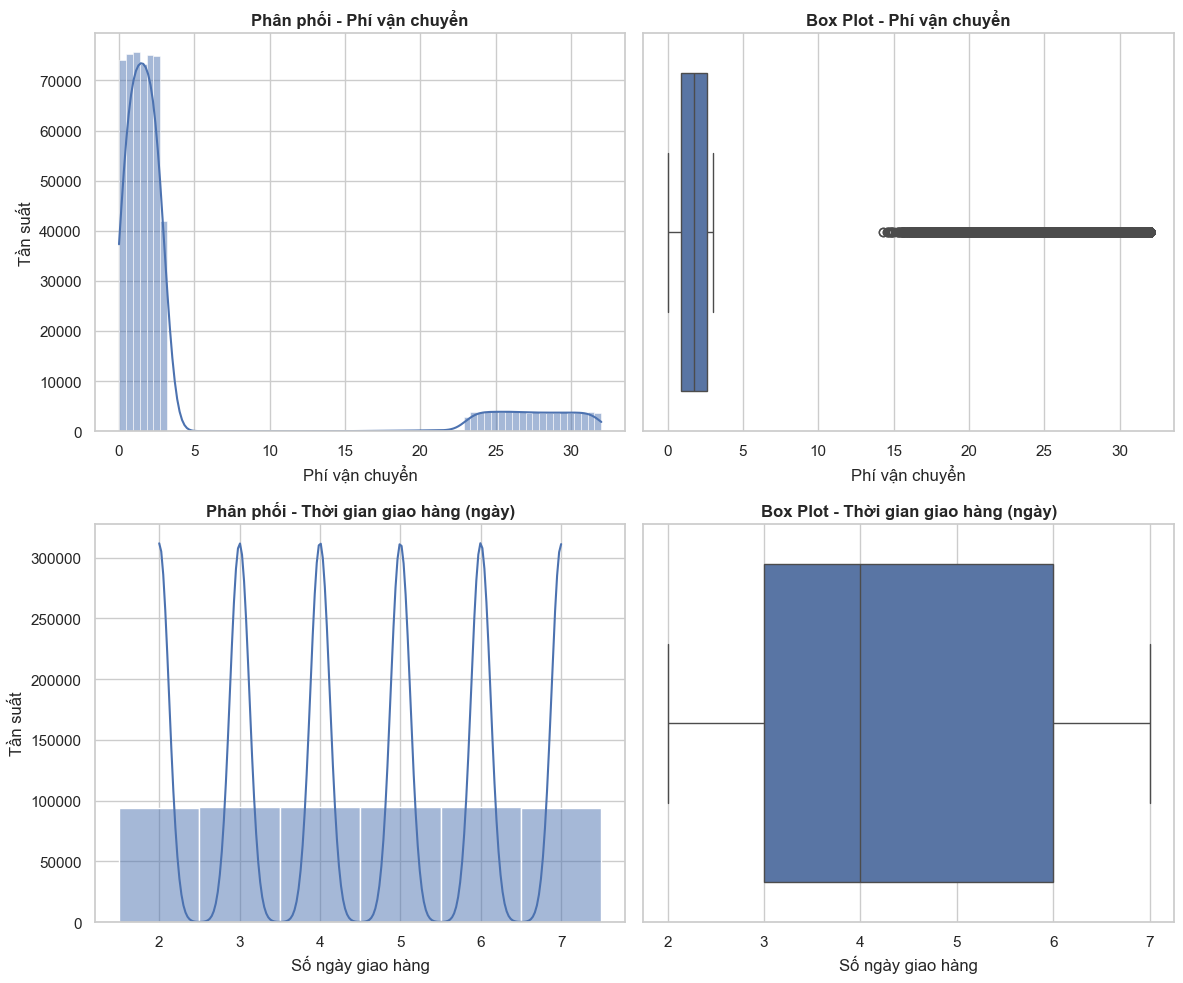

In [ ]:
col_config = {
    'shipping_fee': {
        'title': 'Phí vận chuyển',
        'xlabel': 'Phí vận chuyển',
        'hist_kwargs': {'bins': 70}
    },
    'shipping_lead_time_days': {
        'title': 'Thời gian giao hàng (ngày)',
        'xlabel': 'Số ngày giao hàng',
        'hist_kwargs': {'discrete': True}
    }
}

con_cols_names = ['shipping_fee', 'shipping_lead_time_days']

def format_axis(ax, col_name, values):
    if col_name == 'shipping_lead_time_days':
        ax.set_xticks(sorted(values.unique()))

def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')
        format_axis(ax1, col_name, values)

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])
        format_axis(ax2, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do ket hop tai: {save_path}')

    plt.show()

plot_distribution_boxplot(
    shipments_df,
    con_cols_names,
    save_path=os.path.join(IMAGES_DIR, 'shipments_distribution_boxplot.png')
)

#### b. Thống kê mô tả


In [ ]:
shipments_df[['shipping_fee', 'shipping_lead_time_days']]\
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,shipping_fee,shipping_lead_time_days
count,566067.00,566067.00
mean,4.96,4.50
std,8.89,1.71
min,0.00,2.00
1%,0.04,2.00
5%,0.17,2.00
25%,0.87,3.00
50%,1.73,4.00
75%,2.60,6.00
90%,25.09,7.00


In [ ]:
q1 = shipments_df['shipping_fee'].quantile(0.25)
q3 = shipments_df['shipping_fee'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (shipments_df['shipping_fee'] < lower_bound) | (shipments_df['shipping_fee'] > upper_bound)
outlier_count = int(outlier_mask.sum())
outlier_rate = outlier_count / len(shipments_df) * 100

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Lower bound: {lower_bound:,.2f}')
print(f'Upper bound: {upper_bound:,.2f}')
print(f'So luong outlier (IQR): {outlier_count:,}')
print(f'Ty le outlier (IQR): {outlier_rate:.2f}%')

Q1: 0.87
Q3: 2.60
IQR: 1.73
Lower bound: -1.72
Upper bound: 5.20
So luong outlier (IQR): 76,050
Ty le outlier (IQR): 13.43%


**Nhận xét:**

- **Quan sát:**
  - Phí vận chuyển (`shipping_fee`): Phân bố lệch phải (right-skewed) cực kỳ mạnh. Phần lớn dữ liệu tập trung ở mức phí 0 hoặc rất nhỏ. Boxplot và kết quả IQR ghi nhận một số lượng lớn ngoại lai (outliers) kéo dài về phía đuôi phải (chi phí rất cao).
  - Thời gian giao hàng (`shipping_lead_time_days`): Là một biến dạng số nguyên rời rạc. Dữ liệu hội tụ mật độ cao nhất ở các mốc thời gian chuyển phát tiêu chuẩn (ví dụ 2, 3, 4 ngày). Phân phối cũng có đuôi dài tượng trưng cho các đơn giao hàng chậm trễ.

- **Insights:**
  - Về Phí vận chuyển: Chính sách "Miễn phí vận chuyển" (Freeship) hoặc trợ giá ship cực thấp đang là công cụ chủ đạo được ứng dụng để tối đa hóa chuyển đổi khách hàng. Các điểm ngoại lai có khả năng cao là những đơn hàng có khối lượng/kích thước cồng kềnh (Bulky) hoặc vận chuyển đến các khu vực địa lý xa xôi/hải đảo.
  - Về Lead Time: Hệ thống logistics đang vận hành khá ổn định theo SLA (Service Level Agreement) chuẩn ngắn ngày. Dù vậy, phần đuôi dài (long-tail) của lead time ám chỉ vẫn tồn đọng một lượng đơn hàng bị mắc kẹt, gặp sự cố vận chuyển hoặc khách hàng khó liên lạc.

- **Gợi ý hành động:**
  - Phân tích sâu Outliers: Check chéo nhóm ngoại lai phí cao với tập sản phẩm (`products.csv` - dimension, weight) và địa lý (`geography.csv`) để tạo logic giá cước linh hoạt hơn, tránh bù lỗ quá sâu cho các đơn cồng kềnh đi xa.
  - SLA Monitoring: Nhóm các đơn có `lead_time` vượt ngưỡng chuẩn (vd: > 7 ngày) để đánh giá tỷ lệ hủy đơn/hoàn hàng, từ đó cảnh báo sớm cho đội ngũ CSKH xử lý.

### 1.1.2. Biến phân loại (Categorical)


Da luu bieu do categorical tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/shipments_categorical_distribution.png


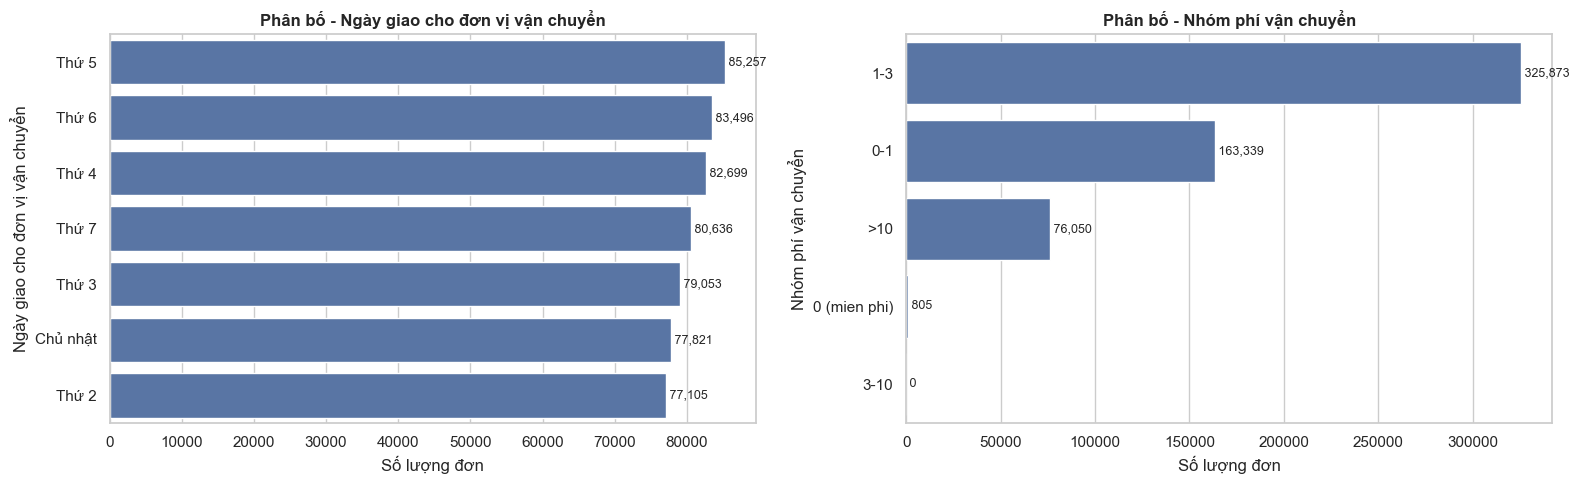

In [ ]:
COL_INFO = {
    'ship_weekday': {'name': 'Ngày giao cho đơn vị vận chuyển', 'unit': 'đơn'},
    'shipping_fee_band': {'name': 'Nhóm phí vận chuyển', 'unit': 'đơn'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('khong_xac_dinh').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhom'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do categorical tai: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    shipments_df,
    ['ship_weekday', 'shipping_fee_band'],
    save_path=os.path.join(IMAGES_DIR, 'shipments_categorical_distribution.png')
)

In [ ]:
weekday_stats = shipments_df['ship_weekday'].value_counts(dropna=False).to_frame(name='count')
weekday_stats['rate_%'] = (weekday_stats['count'] / len(shipments_df) * 100).round(2)
weekday_stats

,count,rate_%
ship_weekday,,
Thứ 5,85257,15.06
Thứ 6,83496,14.75
Thứ 4,82699,14.61
Thứ 7,80636,14.24
Thứ 3,79053,13.97
Chủ nhật,77821,13.75
Thứ 2,77105,13.62


In [ ]:
fee_band_stats = shipments_df['shipping_fee_band'].value_counts(dropna=False).sort_index().to_frame(name='count')
fee_band_stats['rate_%'] = (fee_band_stats['count'] / len(shipments_df) * 100).round(2)
fee_band_stats

,count,rate_%
shipping_fee_band,,
0 (mien phi),805,0.14
0-1,163339,28.86
1-3,325873,57.57
3-10,0,0.00
>10,76050,13.43


**Nhận xét:**

- **Quan sát:**
  - Ngày giao hàng (`ship_weekday`): Khối lượng đơn xuất kho khá đồng đều trong các ngày làm việc (thứ 2 đến thứ 6), tuy nhiên lại sụt giảm đáng kể vào cuối tuần (Thứ 7 và Chủ nhật).
  - Nhóm phí vận chuyển (`shipping_fee_band`): Băng phí thấp hoặc 0 chiếm áp đảo trong khi các băng phí siêu cao (>10) rất hạn chế.

- **Insights:**
  - Nhịp điệu vận hành (Rhythm of operations): Hoạt động xử lý đơn hàng/bàn giao vận chuyển đang có tính chu kỳ tuần rõ nét, chùng xuống theo lịch nghỉ ngơi nhân sự tiêu chuẩn. Khách hàng có xu hướng mua sắm cuối tuần, nhưng đơn sẽ dồn ứ lại và được xử lý ồ ạt vào Thứ 2.
  - Trải nghiệm phí: Cơ cấu nhóm phí lần nữa củng cố việc khách quan tâm cực lớn tới các đơn hàng có dải phí vận chuyển nhỏ bọc lót.

- **Gợi ý hành động:**
  - Tối ưu nhân sự kho bãi: Phân bổ lại ca trực, tăng cường nhân sự Fulfillment vào Chủ chiều/Tối Chủ nhật và đầu ngày Thứ 2 để giải tỏa tình trạng chai lọ/ách tắc (bottleneck) đầu tuần.
  - Segmenting: Phân đoạn khách hàng ưa chuộng Freeship (chỉ mua khi có nhóm phí = 0) vs khách hàng chấp nhận rào cản phí từ 1-3. Đánh giá AOV của 2 nhóm này để tinh chỉnh ngân sách ưu đãi vận chuyển.

### 1.1.3. Biến thời gian


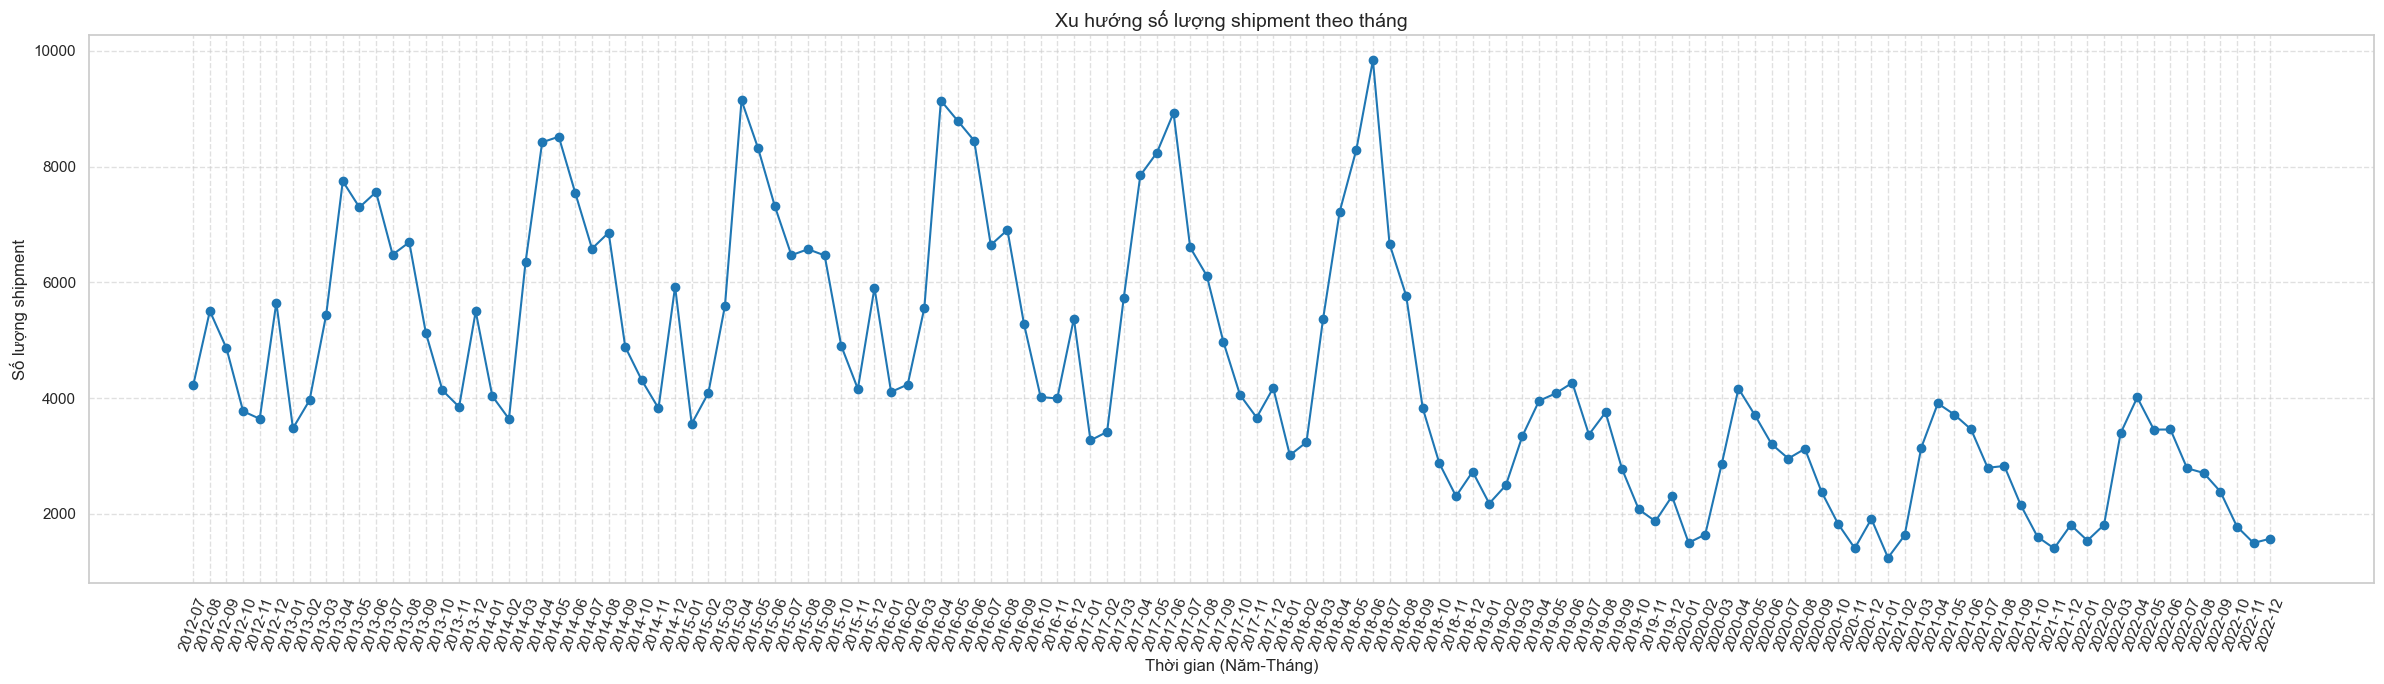

In [ ]:
shipments_df['year_month'] = shipments_df['ship_date'].dt.to_period('M')

monthly_shipments = shipments_df.groupby('year_month').size().reset_index(name='shipment_count')
monthly_shipments['year_month'] = monthly_shipments['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(24, 7))
ax.plot(monthly_shipments['year_month'], monthly_shipments['shipment_count'], color='tab:blue', marker='o', linestyle='-')
ax.set_title('Xu hướng số lượng shipment theo tháng', fontsize=14)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Số lượng shipment')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

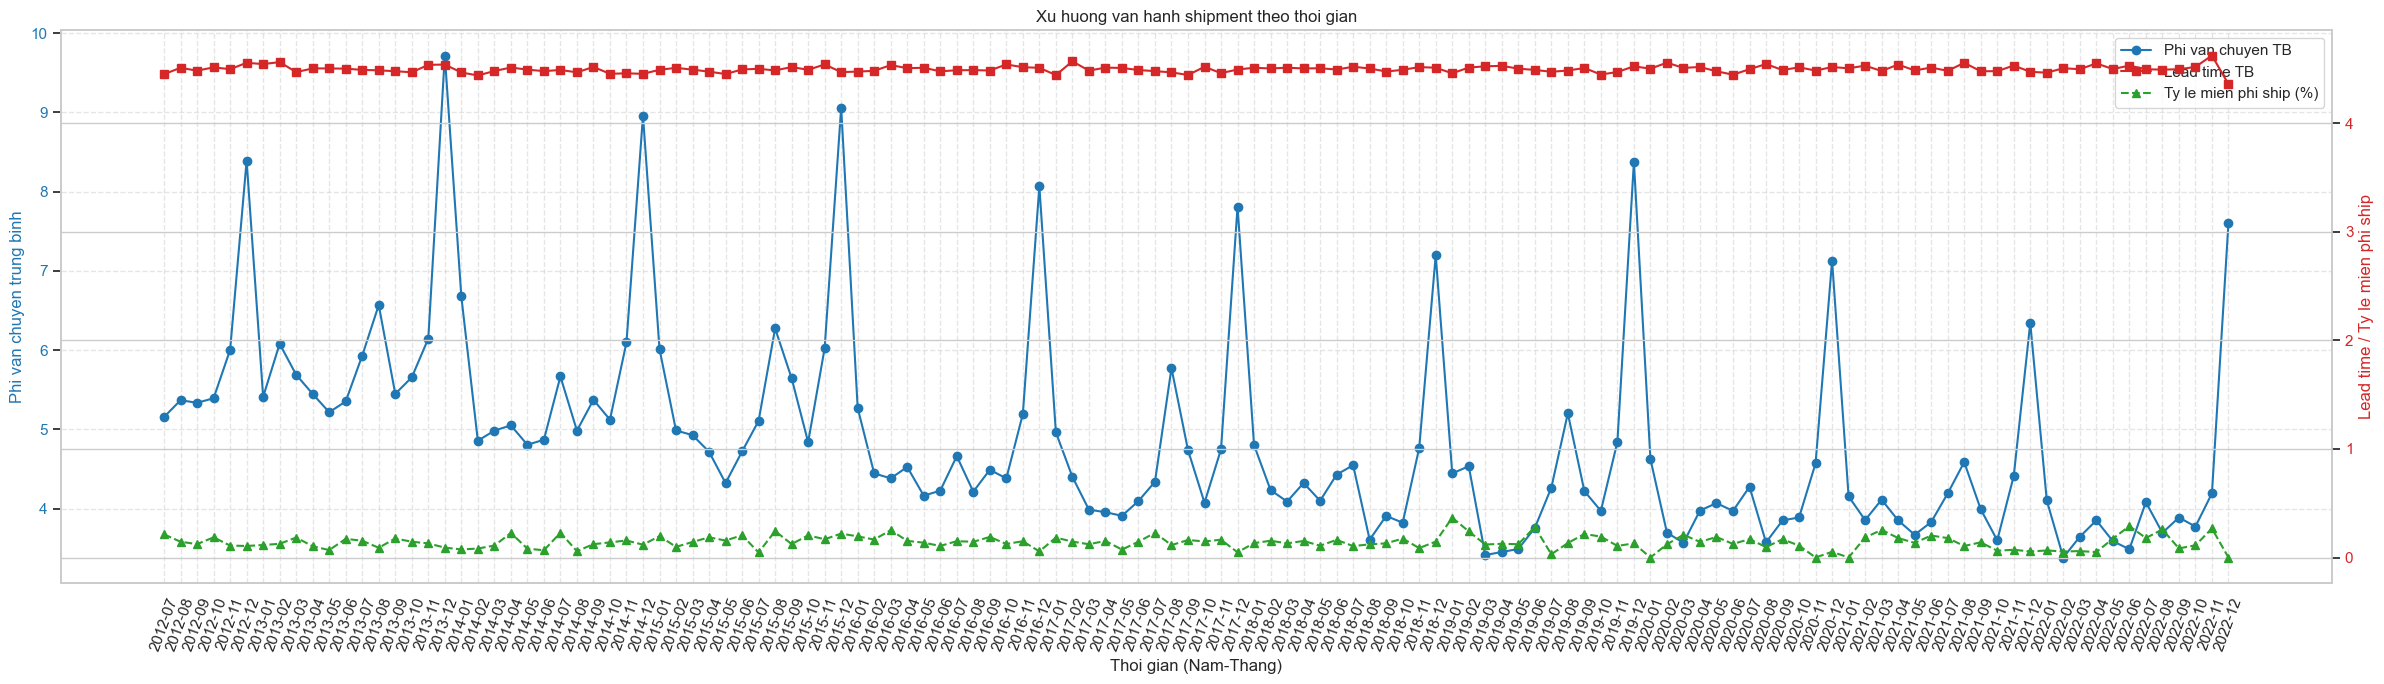

In [ ]:
monthly_operational = shipments_df.groupby('year_month').agg(
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_lead_time_days=('shipping_lead_time_days', 'mean'),
    free_shipping_rate=('shipping_fee', lambda x: (x == 0).mean() * 100)
).reset_index()
monthly_operational['year_month'] = monthly_operational['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(24, 7))

ax1.plot(monthly_operational['year_month'], monthly_operational['avg_shipping_fee'], color='tab:blue', marker='o', label='Phi van chuyen TB')
ax1.set_xlabel('Thoi gian (Nam-Thang)')
ax1.set_ylabel('Phi van chuyen trung binh', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_operational['year_month'], monthly_operational['avg_lead_time_days'], color='tab:red', marker='s', label='Lead time TB')
ax2.plot(monthly_operational['year_month'], monthly_operational['free_shipping_rate'], color='tab:green', marker='^', linestyle='--', label='Ty le mien phi ship (%)')
ax2.set_ylabel('Lead time / Ty le mien phi ship', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.title('Xu huong van hanh shipment theo thoi gian')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Xu hướng số lượng đơn hàng biến thiên liên tục theo từng tháng, có biểu hiện mùa vụ với những đỉnh chóp (peaks) rõ ràng (có thể trùng vào dịp lễ lớn hay Mega Sale).
  - Biều đồ biến động vận hành: Khi tỷ lệ "Miễn phí vận chuyển" tăng cao tại các đỉnh xả hàng, "Lead time trung bình" (thời gian giao hàng) cũng thường có xu hướng giật tăng nhẹ theo, trong khi Phí trung bình giảm xuống.

- **Insights:**
  - Khuyến mãi kích cầu hiệu quả: Rõ ràng việc đẩy mạnh Freeship trong các dịp Sale đã thúc đẩy bùng nổ khối lượng đơn hàng (Volume peak).
  - Đánh đổi vận hành (Operation Trade-off): Các peak volumn kéo theo hiệu ứng phụ là quá tải năng lực xử lý (capacity overload) của đối tác vận chuyển, dẫn đến tình trạng kéo dài Lead Time. Trải nghiệm mong đợi của khách hàng có thể bị giảm sút dù nhận được trợ giá ship.

- **Gợi ý hành động:**
  - Kế hoạch Capacity Planning: Dùng mô hình dự báo Time-series trên dữ liệu hóa đơn giao hàng để ước tính Peak Load trước các kỳ Mega Sale, dự trù thuê thêm kho bãi (3PLs) hoặc hợp tác thêm nhà vận chuyển phụ.
  - Phân tích cân bằng sự hài lòng: Triển khai kiểm tra tỷ lệ đánh giá thấp (`reviews.csv`) ở đúng các tháng có Lead Time giật đỉnh để hiểu hơn sức chịu đựng của khách hàng khi phải đợi hàng xả kho lâu ngày.

## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [ ]:
num_cols = ['shipping_fee', 'shipping_lead_time_days']
corr_df = shipments_df[num_cols].corr()
corr_df

,shipping_fee,shipping_lead_time_days
shipping_fee,1.00,-0.00
shipping_lead_time_days,-0.00,1.00


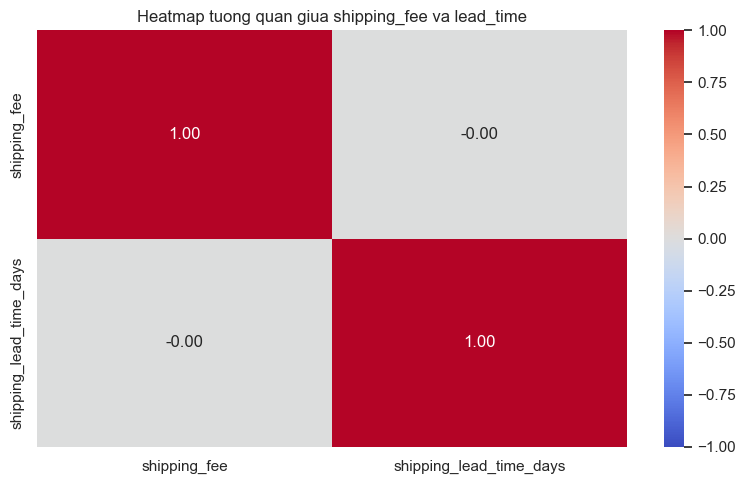

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tuong quan giua shipping_fee va lead_time')
plt.tight_layout()
plt.show()

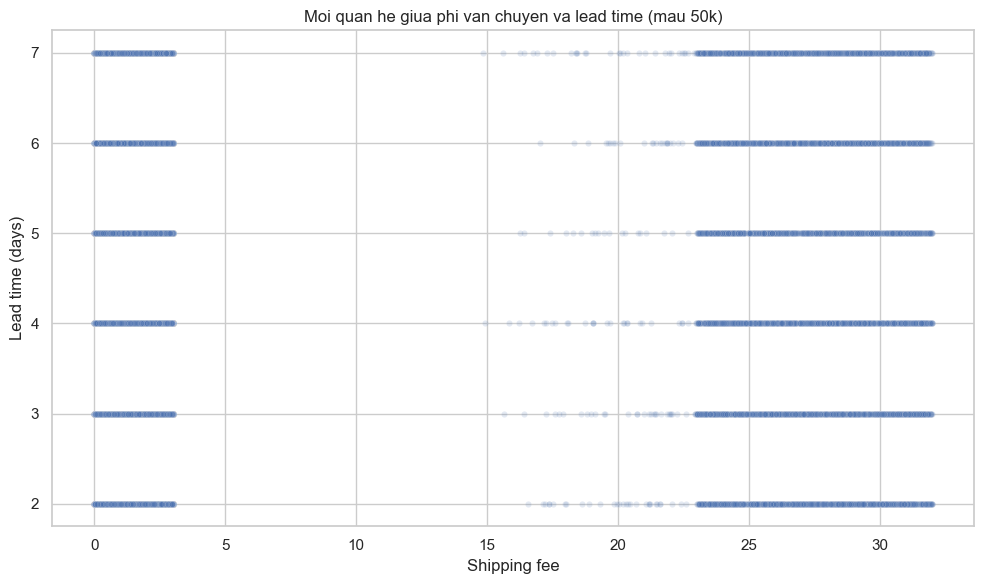

In [ ]:
sample_scatter = shipments_df.sample(n=min(50000, len(shipments_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x='shipping_fee',
    y='shipping_lead_time_days',
    alpha=0.15,
    s=20
)
plt.title('Moi quan he giua phi van chuyen va lead time (mau 50k)')
plt.xlabel('Shipping fee')
plt.ylabel('Lead time (days)')
plt.tight_layout()
plt.show()

### 1.2.2. Phân tích cross table


In [ ]:
cross_abs = pd.crosstab(shipments_df['shipping_fee_band'], shipments_df['shipping_lead_time_days'])
cross_abs

shipping_lead_time_days,2,3,4,5,6,7
shipping_fee_band,,,,,,
0 (mien phi),113,148,142,140,138,124
0-1,27027,27222,27281,27181,27338,27290
1-3,54452,54149,54491,54411,54254,54116
>10,12707,12822,12616,12646,12680,12579


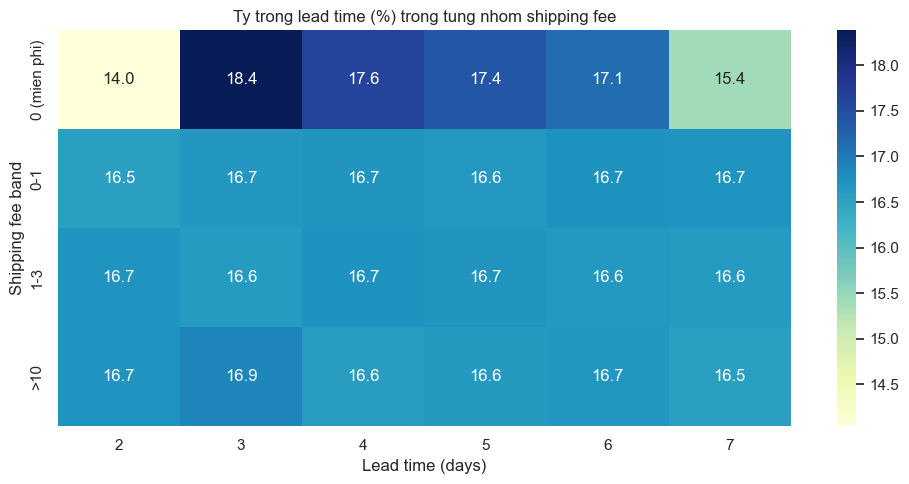

In [ ]:
cross_row_pct = pd.crosstab(
    shipments_df['shipping_fee_band'],
    shipments_df['shipping_lead_time_days'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(cross_row_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Ty trong lead time (%) trong tung nhom shipping fee')
plt.xlabel('Lead time (days)')
plt.ylabel('Shipping fee band')
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Hệ số tương quan (Heatmap) giữa `shipping_fee` và `shipping_lead_time_days` gần như bằng 0 (không có quan hệ tuyến tính).
  - Đồ thị Scatter plot và Crosstab thể hiện rõ: Việc khách hàng trả cước vận chuyển cao KHÔNG đồng nghĩa họ nhận được hàng hóa trong số ngày ngắn hơn. Nhóm được Miễn phí ship (band 0) vẫn nhận hàng nhanh tương đương nhóm cước cao.

- **Insights:**
  - Cơ chế cước phí dựa trên đặc tính vật lý/địa lý: Cấu trúc tính giá ship hiện tại cấu thành bởi Kích cỡ hàng và Quãng đường (Khoảng cách vùng miền) chứ không phản ánh gói "Tốc độ" (Express 1-2h/Same-day).
  - Trải nghiệm công bằng: Điểm sáng là sự đối xử đồng đều; voucher Freeship không làm hệ thống cố tình hãm tốc độ giao hàng (ưu tiên thấp) của kiện hàng đó đi. Khách hàng được tận hưởng tốc độ như các đơn tính phí thông thường.

- **Gợi ý hành động:**
  - Ra mắt Dịch vụ hỏa tốc: Khoảng trống tương quan ngụ ý hiện doanh nghiệp đang thiếu (hoặc chưa chẻ luồng rành mạch) mảng dịch vụ "Giao tốc hành - Trả phí cao" (Premium Express Service). Cân nhắc tung ra dịch vụ thu phí Extra để giao 24h đối với khách hàng ưu tiên thời gian tại khu vực Thành phố lớn.
  - Nhúng biến Machine Learning: Không kết hợp chung Fee và Lead Time bằng các thao tác tương tác như chia/nhân vì bản chất chúng độc lập định tuyến. Sử dụng chúng như hai feature độc lập khi huấn luyện Gradient Boosting / Random Forest cho Customer Churn Return.

### **Câu hỏi: Sự thay đổi trong hành vi và xu hướng thanh toán qua các tháng tác động như thế nào đến tổng doanh thu của hệ thống?**

#### Câu hỏi nhỏ 1: Tỷ trọng của các phương thức thanh toán trả trước (Credit Card, Paypal, Apple Pay) so với trả sau (COD) có sự dịch chuyển ra sao trong những tháng đạt đỉnh (peak) doanh thu?

#### Câu hỏi nhỏ 2: Việc ưu đãi hoặc mở rộng các lựa chọn trả góp (installments) ở kỳ hạn dài (6-12 tháng) có thực sự thúc đẩy sự gia tăng của Giá trị đơn hàng trung bình (AOV) theo thời gian hay không?

#### Câu hỏi nhỏ 3: Tỷ lệ giao dịch lỗi, từ chối thanh toán hoặc hủy đơn có xu hướng tăng đột biến vào các chu kỳ có volume thanh toán tăng mạnh (như mùa lễ hội/Mega Sale) gây rò rỉ doanh thu không?